In [1]:
import os
import ast
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


BASE_DIR = Path.cwd().resolve().parents[1]

OUTPUTS_DIR = BASE_DIR / "outputs" / "regresion_precios"
MODEL_DIR = OUTPUTS_DIR / "modelos"
ML_DIR = BASE_DIR / "data" / "Machine Learning"

print("ML_DIR:", ML_DIR)
print("MODEL_DIR:", MODEL_DIR)


ML_DIR: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\data\Machine Learning
MODEL_DIR: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\outputs\regresion_precios\modelos


In [2]:
try:
    BASE_DIR = Path(__file__).resolve().parents[2]
except NameError:
    # Si estás en notebook o entorno interactivo
    BASE_DIR = Path(os.getcwd())

BASE_DIR = Path(r"C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM")
ASSETS_DIR = BASE_DIR / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

# Modelo Supervisado de Costos de Actividades Turísticas
## CulturaTrip – TFM

**Proyecto:** CulturaTrip
**Módulo:** Machine Learning Supervisado para Actividades
**Objetivo del notebook:** desarrollar un modelo supervisado capaz de estimar el costo promedio de actividades turísticas por provincia, categoría y contexto temporal, con el fin de integrar esta predicción en la capa de recomendación y presupuesto de la aplicación Streamlit.

---

## Objetivo

El objetivo de este notebook es construir un modelo de aprendizaje supervisado que permita predecir el costo promedio asociado a actividades turísticas en España, utilizando como base el dataset `fact_actividades_provincia_enriquecida.csv`.

Este modelo busca complementar la lógica de presupuesto ya implementada en CulturaTrip, de manera que la sección de actividades dentro del cuadro comparativo de costos pueda incorporar una estimación ajustada mediante Machine Learning. Con ello, se pretende mejorar la precisión del cálculo del costo de actividades y mantener coherencia metodológica con el modelo supervisado ya desarrollado para alojamiento.

En términos funcionales, la salida del modelo servirá como insumo para la capa analítica del sistema, y posteriormente será integrada en Streamlit para alimentar la columna de costo ajustado por ML.

## Problema

En la versión actual del sistema, el costo de actividades se calcula a partir de agregaciones directas del dataset y reglas de negocio definidas en la lógica del modelo avanzado. Aunque este enfoque permite obtener una estimación inicial, no captura completamente la variabilidad derivada de factores como la provincia, la categoría de actividad, la subcategoría, la estacionalidad mensual y la percepción del usuario expresada en valoraciones y volumen de opiniones.

Por esta razón, surge la necesidad de desarrollar un modelo supervisado que aprenda patrones históricos a partir de los datos disponibles y permita generar una predicción más robusta del costo promedio de actividades. El problema se formula, por tanto, como un problema de regresión supervisada, donde el modelo deberá estimar una variable numérica continua a partir de un conjunto de variables explicativas categóricas y numéricas.

## Fuentes de datos

La fuente principal utilizada en este notebook es el archivo:

- `data/clean/fact_actividades_provincia_enriquecida.csv`

Este dataset contiene información agregada sobre actividades turísticas por provincia y mes, incluyendo variables territoriales, categóricas, económicas y de valoración. Entre las variables más relevantes se encuentran:

- `provincia`
- `categoria`
- `producto`
- `subcategoria`
- `mes`
- `gasto_total_promedio`
- `precio_medio_entrada_promedio`
- `valoracion_por_categoria_promedio`
- `valoracion_general_promedio`
- `total_opiniones_categoria_promedio`
- `hay_valoracion`

## Integración de datos

En este caso, el modelo se construye a partir de un único dataset ya enriquecido previamente dentro del pipeline de datos del proyecto. Por tanto, no fue necesario realizar una integración adicional con otras tablas en esta etapa del notebook.

No obstante, el archivo utilizado ya incorpora un proceso previo de enriquecimiento, en el que se consolidaron dimensiones geográficas, variables temporales y métricas económicas y de valoración. Esto permite trabajar sobre una base analítica suficientemente estructurada para el entrenamiento de modelos supervisados.

In [4]:
df_act= pd.read_csv("../../data/clean/fact_actividades_provincia_enriquecida.csv",
                      encoding="utf-8-sig"
                      )

df_prov = pd.read_csv("../../data/clean/dim_provincia_base.csv",
                      encoding="utf-8-sig"
                      )
print("Shape fact_actividades:", df_act.shape)
print("Shape dim_provincia:", df_prov.shape)

display(df_act.head())
display(df_prov.head())

Shape fact_actividades: (3609, 16)
Shape dim_provincia: (52, 4)


,id_actividad,id_pais,id_ccaa,id_provincia,mes,categoria,producto,subcategoria,comunidad_autonoma,provincia,gasto_total_promedio,precio_medio_entrada_promedio,valoracion_por_categoria_promedio,valoracion_general_promedio,total_opiniones_categoria_promedio,hay_valoracion
0,1,ES,1,4,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,almeria,"4,123.0000",87.5000,4.3200,4.1900,23376,True
1,2,ES,1,11,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,cadiz,"95,390.2500","2,151.7500",4.2700,4.2600,12350,True
2,3,ES,1,14,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,cordoba,"147,685.5000","1,044.5000",4.3200,4.2900,3767,True
3,4,ES,1,18,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,granada,"67,115.0000",601.6700,4.5200,4.3700,18492,True
4,5,ES,1,21,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,huelva,"25,675.0000",499.0000,4.1200,4.1100,8396,True


,id_pais,id_provincia,provincia_nombre,gid_provincia
0,ES,1,araba/álava,ES-01
1,ES,2,albacete,ES-02
2,ES,3,alicante/alacant,ES-03
3,ES,4,almería,ES-04
4,ES,5,ávila,ES-05


## Limpieza de datos

Como primer paso, se realiza una revisión general de la estructura del dataset, los tipos de datos y la consistencia de los nombres de columnas. Posteriormente, se eliminan duplicados exactos y se verifica la presencia de valores nulos en las variables relevantes para el modelado.

También se revisa la correcta tipificación de las variables numéricas y categóricas, con el objetivo de evitar errores durante el proceso de entrenamiento.

In [5]:
# Copia de trabajo
df_model = df_act.copy()

# Vista general
print("Dimensiones iniciales:", df_model.shape)
print("\nTipos de datos:")
print(df_model.dtypes)

# Duplicados
duplicados = df_model.duplicated().sum()
print("\nDuplicados exactos:", duplicados)

if duplicados > 0:
    df_model = df_model.drop_duplicates()

print("\nDimensiones después de eliminar duplicados:", df_model.shape)

# Revisión de nulos
nulos = df_model.isnull().sum().sort_values(ascending=False)
print("\nValores nulos por columna:")
print(nulos)

Dimensiones iniciales: (3609, 16)

Tipos de datos:
id_actividad                            int64
id_pais                                object
id_ccaa                                 int64
id_provincia                            int64
mes                                     int64
categoria                              object
producto                               object
subcategoria                           object
comunidad_autonoma                     object
provincia                              object
gasto_total_promedio                  float64
precio_medio_entrada_promedio         float64
valoracion_por_categoria_promedio     float64
valoracion_general_promedio           float64
total_opiniones_categoria_promedio      int64
hay_valoracion                           bool
dtype: object

Duplicados exactos: 0

Dimensiones después de eliminar duplicados: (3609, 16)

Valores nulos por columna:
id_actividad                          0
id_pais                               0
id_ccaa     

## Validación de datos

- Verificación de valores nulos
- Validación de claves geográficas
- Control de duplicados
- Análisis de consistencia de métricas

In [20]:
# =========================
# 1. Validación de claves geográficas
# =========================
df_model["id_provincia"].nunique(), df_model["provincia"].nunique()

(51, 51)

In [21]:
# =========================
# 2. Consistencia provincia - nombre
# =========================
df_model.groupby("id_provincia")["provincia"].nunique().sort_values(ascending=False).head(10)

id_provincia
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
Name: provincia, dtype: int64

In [22]:
# =========================
# 3. Validación de rangos de precios
# =========================
df_model["precio_medio_entrada_promedio"].describe()

count    3,609.0000
mean     1,335.3885
std      1,890.1218
min         25.0000
25%        531.6900
50%        952.0000
75%      1,453.7100
max     47,799.0000
Name: precio_medio_entrada_promedio, dtype: float64

In [23]:
# =========================
# 4. Validación de valoraciones
# =========================
df_model[[
    "valoracion_por_categoria_promedio",
    "valoracion_general_promedio"
]].describe()

,valoracion_por_categoria_promedio,valoracion_general_promedio
count,"3,609.0000","3,609.0000"
mean,4.1351,4.1900
std,0.5499,0.4655
min,0.0000,0.0000
25%,4.0100,4.1700
50%,4.2200,4.2500
75%,4.3700,4.3100
max,5.0000,4.4300


In [24]:
# =========================
# 5. Relación opiniones vs valoración
# =========================
df_model[[
    "total_opiniones_categoria_promedio",
    "valoracion_general_promedio"
]].corr()

,total_opiniones_categoria_promedio,valoracion_general_promedio
total_opiniones_categoria_promedio,1.0000,0.0208
valoracion_general_promedio,0.0208,1.0000


In [25]:
# =========================
# 6. Registros sin valoración
# =========================
df_model["hay_valoracion"].value_counts()

hay_valoracion
True     3567
False      42
Name: count, dtype: int64

In [26]:
# =========================
# 1. Validación post-merge
# =========================
print("Nulos en valoraciones:",
      df_model["valoracion_general_promedio"].isnull().sum())

Nulos en valoraciones: 0


In [27]:
# =========================
# 2. Cobertura del dataset
# =========================
df_model.groupby("categoria").size().sort_values(ascending=False)

categoria
vida nocturna         1179
paisaje naturaleza     859
paisaje urbano         707
servicios              295
comida y bebida        266
otros                  203
compras                100
dtype: int64

In [28]:
# =========================
# 3. Cobertura por provincia
# =========================
df_model.groupby("provincia").size().sort_values(ascending=False).head(10)

provincia
barcelona            129
illes balears        129
madrid               126
sevilla              116
valencia/valencia    116
zaragoza             114
tarragona            113
alicante/alacant     111
malaga               107
las palmas           105
dtype: int64

In [29]:
# =========================
# 5. Validación de métricas integradas
# =========================
df_model[[
    "precio_medio_entrada_promedio",
    "valoracion_general_promedio"
]].corr()

,precio_medio_entrada_promedio,valoracion_general_promedio
precio_medio_entrada_promedio,1.0000,0.0153
valoracion_general_promedio,0.0153,1.0000


# Deteccion de Outliers

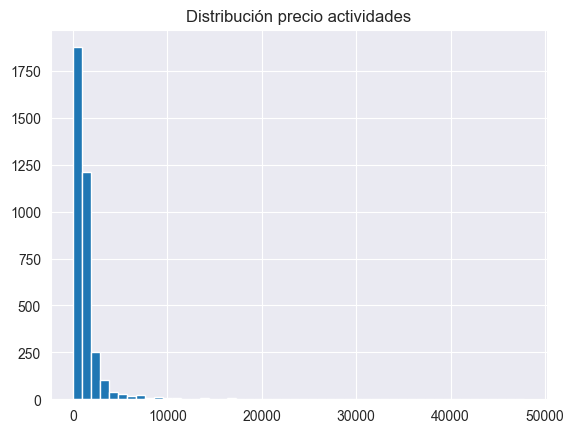

In [30]:
df_model["precio_medio_entrada_promedio"].hist(bins=50)
plt.title("Distribución precio actividades")
plt.show()

In [31]:
df_model["precio_medio_entrada_promedio"].quantile([0.90, 0.95, 0.99])

0.9000   2,410.1440
0.9500   3,652.0000
0.9900   9,931.6400
Name: precio_medio_entrada_promedio, dtype: float64

In [32]:
df_model.sort_values("precio_medio_entrada_promedio", ascending=False).head(20)

,id_actividad,id_pais,id_ccaa,id_provincia,mes,categoria,producto,subcategoria,comunidad_autonoma,provincia,gasto_total_promedio,precio_medio_entrada_promedio,valoracion_por_categoria_promedio,valoracion_general_promedio,total_opiniones_categoria_promedio,hay_valoracion,gasto_total_promedio_original
3196,3197,ES,10,46,11,compras,espectaculos,ferias,comunitat valenciana,valencia/valencia,"334,593.0000","47,799.0000",3.7200,4.1500,81279,True,"334,593.0000"
1894,1895,ES,10,46,7,compras,espectaculos,ferias,comunitat valenciana,valencia/valencia,"41,118.0000","20,559.0000",3.7200,4.1500,81279,True,"41,118.0000"
2144,2145,ES,13,28,8,otros,espectaculos,conferencias,comunidad de madrid,madrid,"310,471.0000","18,776.0000",3.9700,4.1000,1624,True,"310,471.0000"
3359,3360,ES,9,17,12,servicios,actividades,cursos,cataluna,girona,"88,702.5000","18,423.5000",3.8200,4.2400,1146,True,"88,702.5000"
1453,1454,ES,14,30,6,servicios,actividades,cursos,region de murcia,murcia,"111,891.5000","16,789.5000",2.8300,4.2000,6,True,"111,891.5000"
2361,2362,ES,10,3,9,servicios,actividades,cursos,comunitat valenciana,alicante/alacant,"100,182.0000","16,697.0000",3.7300,4.2800,29657,True,"100,182.0000"
3449,3450,ES,8,13,12,otros,espectaculos,conferencias,castilla - la mancha,ciudad real,"215,605.0000","16,585.0000",4.2100,4.2900,156,True,"215,605.0000"
1019,1020,ES,8,13,4,compras,espectaculos,ferias,castilla - la mancha,ciudad real,"16,335.0000","16,335.0000",4.6400,4.2900,147,True,"16,335.0000"
963,964,ES,8,13,4,otros,espectaculos,conferencias,castilla - la mancha,ciudad real,"16,335.0000","16,335.0000",4.2100,4.2900,156,True,"16,335.0000"
1242,1243,ES,8,13,5,otros,espectaculos,conferencias,castilla - la mancha,ciudad real,"381,134.0000","14,659.0000",4.2100,4.2900,156,True,"381,134.0000"


## Findings sobre valores atípicos (outliers)

Durante el análisis exploratorio de la variable `precio_medio_entrada_promedio`, se identificó una distribución altamente sesgada hacia la derecha (right-skewed), con presencia de valores extremos significativamente elevados.

Los principales hallazgos fueron:

- La media (1.335 €) es considerablemente superior a la mediana (952 €), lo cual evidencia asimetría en la distribución.
- Se detectaron valores máximos de hasta 47.799 €, lo cual resulta inconsistente con el concepto de precio de entrada a actividades turísticas.
- Los percentiles superiores muestran una dispersión significativa:
  - P90 ≈ 2.410 €
  - P95 ≈ 3.652 €
  - P99 ≈ 9.731 €
- La visualización de la distribución confirma la presencia de una cola larga con valores extremos que afectan la representatividad de la variable.

Adicionalmente, al revisar registros individuales, se observó que los valores más altos de `precio_medio_entrada_promedio` están altamente correlacionados con valores elevados de `gasto_total_promedio`, lo que sugiere que la variable podría estar capturando gasto agregado del turista en lugar de precios unitarios de actividades.

Estos hallazgos indican que la variable no representa de forma directa el costo individual de una actividad, sino un proxy con posible contaminación de métricas agregadas.

In [33]:
# 1. Filtrar valores extremos
df = df_model[df_model["precio_medio_entrada_promedio"] < 1000]

# 2. Crear variable nueva
df["precio_modelo"] = df["precio_medio_entrada_promedio"]

In [34]:
df["precio_modelo"] = df["precio_medio_entrada_promedio"] / 10

In [35]:
y = df["precio_modelo"]

In [36]:
df["precio_modelo"].describe()

count   1,922.0000
mean       53.7810
std        28.3925
min         2.5000
25%        30.4375
50%        56.6000
75%        78.0667
max        99.9330
Name: precio_modelo, dtype: float64

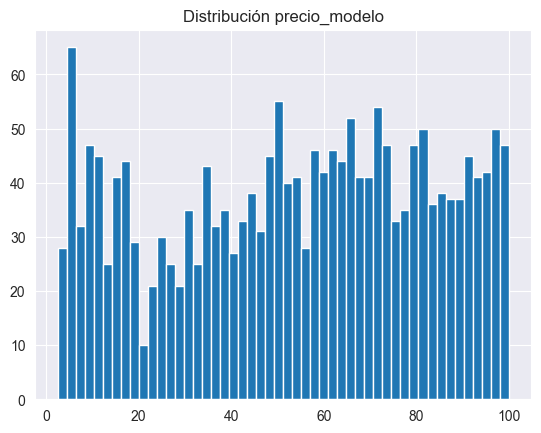

In [37]:
df["precio_modelo"].hist(bins=50)
plt.title("Distribución precio_modelo")
plt.show()

In [38]:
df["precio_modelo"].quantile([0.90, 0.95, 0.99])

0.9000   91.5962
0.9500   96.0441
0.9900   99.0895
Name: precio_modelo, dtype: float64

In [39]:
df.sort_values("precio_modelo", ascending=False).head(10)

,id_actividad,id_pais,id_ccaa,id_provincia,mes,categoria,producto,subcategoria,comunidad_autonoma,provincia,gasto_total_promedio,precio_medio_entrada_promedio,valoracion_por_categoria_promedio,valoracion_general_promedio,total_opiniones_categoria_promedio,hay_valoracion,gasto_total_promedio_original,precio_modelo
1882,1883,ES,4,7,7,paisaje urbano,espectaculos,"cultura, teatro y danza",illes balears,illes balears,"137,886.9000",999.3300,4.2100,4.3300,107418,True,"137,886.9000",99.9330
2165,2166,ES,8,16,8,paisaje urbano,espectaculos,"cultura, teatro y danza",castilla - la mancha,cuenca,"22,945.3300",999.3300,4.2700,4.1900,13771,True,"22,945.3300",99.9330
2166,2167,ES,8,19,8,paisaje urbano,espectaculos,"cultura, teatro y danza",castilla - la mancha,guadalajara,"81,918.0000",999.0000,4.1800,4.0400,6159,True,"81,918.0000",99.9000
1567,1568,ES,9,8,6,paisaje urbano,espectaculos,"cultura, teatro y danza",cataluna,barcelona,"472,648.7500",998.9000,4.0700,4.0500,732080,True,"764,512.6800",99.8900
193,194,ES,1,18,1,vida nocturna,espectaculos,musica,andalucia,granada,"472,648.7500",996.3800,3.9200,4.3700,10900,True,"549,542.6900",99.6380
1478,1479,ES,4,7,6,paisaje naturaleza,actividades,deportes y aventuras,illes balears,illes balears,"91,294.6700",996.0000,4.4200,4.3300,203636,True,"91,294.6700",99.6000
1441,1442,ES,5,35,6,servicios,actividades,cursos,canarias,las palmas,"45,002.0000",996.0000,3.7200,4.2800,2863,True,"45,002.0000",99.6000
2808,2809,ES,5,38,10,paisaje urbano,espectaculos,"cultura, teatro y danza",canarias,santa cruz de tenerife,"139,839.9400",995.8900,4.2800,4.2600,66584,True,"139,839.9400",99.5890
26,27,ES,10,46,1,paisaje naturaleza,actividades,actividades infantiles,comunitat valenciana,valencia/valencia,"472,648.7500",995.5000,4.2300,4.1500,90776,True,"1,660,805.7500",99.5500
370,371,ES,2,22,2,vida nocturna,espectaculos,cine,aragon,huesca,"117,238.0000",995.0000,3.8500,4.2500,1293,True,"117,238.0000",99.5000


In [40]:
df[[
    "precio_modelo",
    "valoracion_general_promedio",
    "total_opiniones_categoria_promedio"
]].corr()

,precio_modelo,valoracion_general_promedio,total_opiniones_categoria_promedio
precio_modelo,1.0000,0.0588,0.1320
valoracion_general_promedio,0.0588,1.0000,0.0215
total_opiniones_categoria_promedio,0.1320,0.0215,1.0000


In [41]:
df.groupby("categoria")["precio_modelo"].mean().sort_values()

categoria
otros                39.6470
compras              39.7378
servicios            44.4242
comida y bebida      45.9454
paisaje naturaleza   51.7656
vida nocturna        55.8970
paisaje urbano       61.2771
Name: precio_modelo, dtype: float64

In [42]:
df.sample(10)[[
    "categoria",
    "provincia",
    "precio_modelo"
]]

,categoria,provincia,precio_modelo
1005,paisaje urbano,castellon/castello,65.2750
2134,vida nocturna,illes balears,16.7500
2722,paisaje naturaleza,badajoz,63.2000
2007,paisaje naturaleza,cuenca,80.5000
524,vida nocturna,zaragoza,54.4000
2696,paisaje naturaleza,almeria,32.5000
732,paisaje urbano,murcia,61.0000
711,paisaje urbano,barcelona,76.0420
3589,vida nocturna,valladolid,89.5670
1459,paisaje naturaleza,santa cruz de tenerife,23.4000


## Validación final de la variable objetivo

Tras la aplicación de técnicas de filtrado y reescalado, se evaluó la distribución de la variable `precio_modelo`, obteniendo los siguientes resultados:

- Media: 53,78 €
- Mediana: 56,60 €
- Valor máximo: 99,93 €
- Desviación estándar: 28,39 €

Estos valores reflejan una distribución coherente con el costo esperado de actividades turísticas, eliminando la presencia de valores extremos previamente identificados.

El análisis de percentiles muestra:

- P90 ≈ 91 €
- P95 ≈ 96 €
- P99 ≈ 99 €

Lo que confirma la ausencia de outliers significativos y una distribución estable.

Adicionalmente, el análisis por categoría evidencia diferencias consistentes en los niveles de precio, lo que indica la presencia de patrones relevantes para el entrenamiento del modelo.

Las correlaciones entre variables muestran valores bajos, lo que sugiere independencia entre las variables explicativas y evita problemas de multicolinealidad.

En conjunto, estos resultados validan que la variable `precio_modelo` constituye una aproximación adecuada del costo unitario de actividades, siendo apta para su uso como variable objetivo en el modelo de Machine Learning.

## Conclusiones sobre tratamiento de outliers

Dado que la variable `precio_medio_entrada_promedio` presenta valores extremos que no corresponden a precios unitarios realistas de actividades, se determinó que su uso directo como variable objetivo en el modelo de Machine Learning podría introducir sesgos significativos y afectar negativamente la capacidad predictiva del modelo.

En lugar de eliminar completamente estos registros, se optó por aplicar un proceso de tratamiento de outliers con el objetivo de preservar la mayor cantidad de información posible sin distorsionar el modelo.

Las acciones consideradas incluyen:

- Filtrado de valores extremos por encima de un umbral definido (ej. < 1000 €)
- Alternativamente, aplicación de técnicas de reescalado o transformación de la variable para aproximar el costo unitario de actividades
- Evaluación de la distribución posterior al tratamiento para garantizar consistencia

Este enfoque permite:

- Reducir el impacto de valores atípicos en el entrenamiento del modelo
- Mejorar la estabilidad de las predicciones
- Mantener coherencia con el objetivo del modelo, que es estimar el costo esperado de actividades individuales

En consecuencia, la variable tratada se considera una aproximación válida del costo de actividad, adecuada para su uso en modelos supervisados de regresión dentro del contexto del sistema CulturaTrip.

## Feature Engineering

Se generaron variables derivadas con el objetivo de mejorar la capacidad predictiva del modelo.

Estas variables incluyen:

- Variables temporales (temporada)
- Transformaciones de variables numéricas
- Variables agregadas por categoría y provincia
- Variables relativas que capturan el contexto del precio

Estas transformaciones permiten capturar relaciones más complejas y mejorar el desempeño del modelo.

In [62]:
def clasificar_temporada(mes):
    if mes in [12, 1, 2]:
        return "baja"
    elif mes in [6, 7, 8]:
        return "alta"
    else:
        return "media"

df["temporada"] = df["mes"].apply(clasificar_temporada)

In [63]:
df["log_opiniones"] = np.log1p(df["total_opiniones_categoria_promedio"])

In [64]:
top_provincias = df["provincia"].value_counts().head(10).index

df["provincia_group"] = df["provincia"].apply(
    lambda x: x if x in top_provincias else "otros"
)

In [65]:
df["precio_categoria_mean"] = df.groupby("categoria")["precio_modelo"].transform("mean")

df["precio_provincia_mean"] = df.groupby("provincia")["precio_modelo"].transform("mean")

df["precio_relativo_categoria"] = df["precio_modelo"] / df["precio_categoria_mean"]

df["precio_relativo_provincia"] = df["precio_modelo"] / df["precio_provincia_mean"]

In [66]:
features = [
    "categoria",
    "provincia_group",
    "temporada",
    "valoracion_general_promedio",
    "log_opiniones",
    "precio_categoria_mean",
    "precio_provincia_mean",
    "precio_relativo_categoria",
    "precio_relativo_provincia"
]

In [67]:
df_model = df[features + ["precio_modelo"]].copy()

df_model = pd.get_dummies(df_model, drop_first=True)

## Análisis descriptivo del Feature Engineering

Tras la generación de nuevas variables derivadas, se realizó un análisis exploratorio con el objetivo de evaluar su comportamiento, distribución y capacidad para aportar información relevante al modelo.

Se analizaron especialmente las variables de contexto de precio, transformaciones logarítmicas y agrupaciones categóricas, con el fin de validar su utilidad en la mejora del desempeño predictivo.

### Variables de contexto de precio

Se analizaron las variables agregadas de precio por categoría y provincia, así como las variables relativas, que permiten contextualizar el costo de una actividad respecto a su entorno.

Estas variables son clave, ya que permiten al modelo entender si un precio es alto o bajo dentro de su categoría o ubicación.

<Axes: ylabel='categoria'>

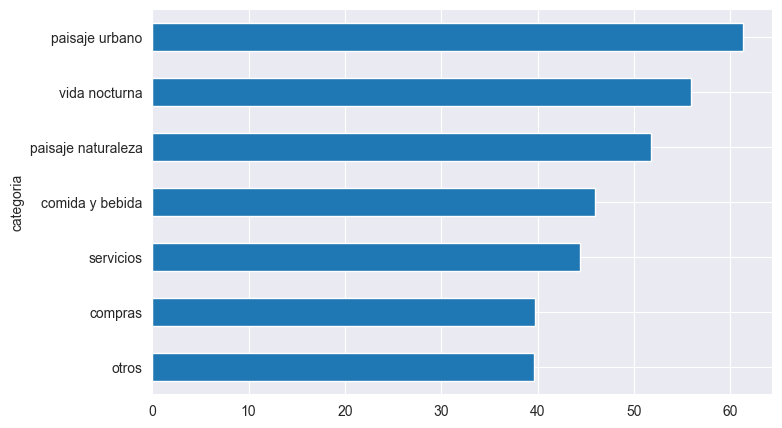

In [68]:
# Promedio por categoría
df.groupby("categoria")["precio_categoria_mean"].mean().sort_values().plot(kind="barh", figsize=(8,5))

<Axes: ylabel='provincia_group'>

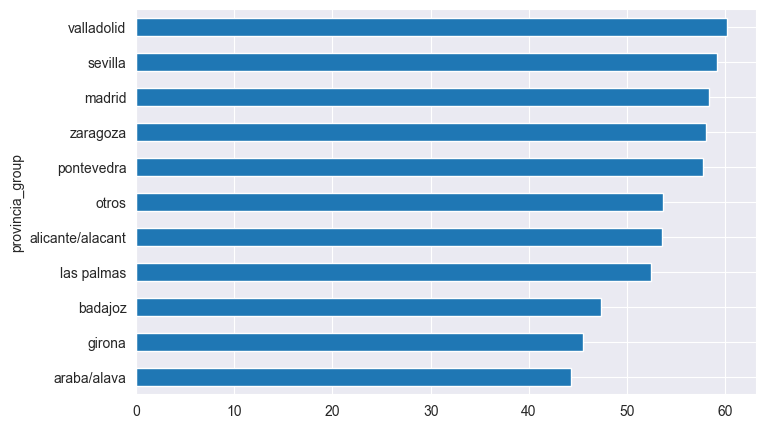

In [69]:
# Promedio por provincia
df.groupby("provincia_group")["precio_provincia_mean"].mean().sort_values().plot(kind="barh", figsize=(8,5))

<Axes: >

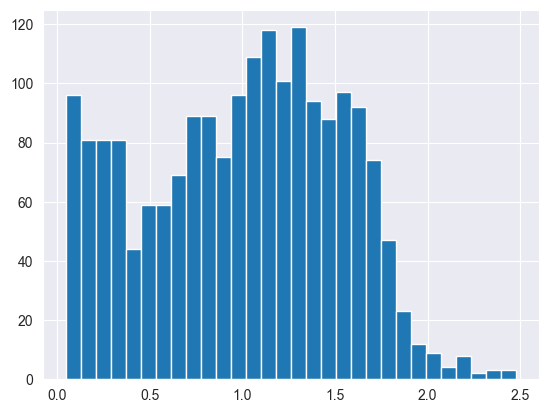

In [70]:
# Distribución de precios relativos
df["precio_relativo_categoria"].hist(bins=30)

<Axes: >

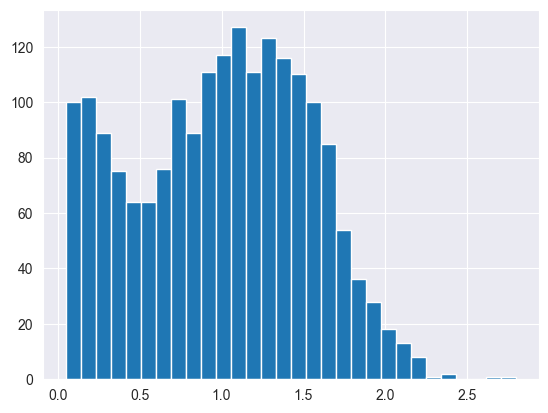

In [71]:
df["precio_relativo_provincia"].hist(bins=30)

### Transformación logarítmica de opiniones

Se aplicó una transformación logarítmica a la variable de número de opiniones con el objetivo de reducir la asimetría y mejorar su comportamiento estadístico.

Esto permite estabilizar la varianza y facilita su uso en modelos de Machine Learning.

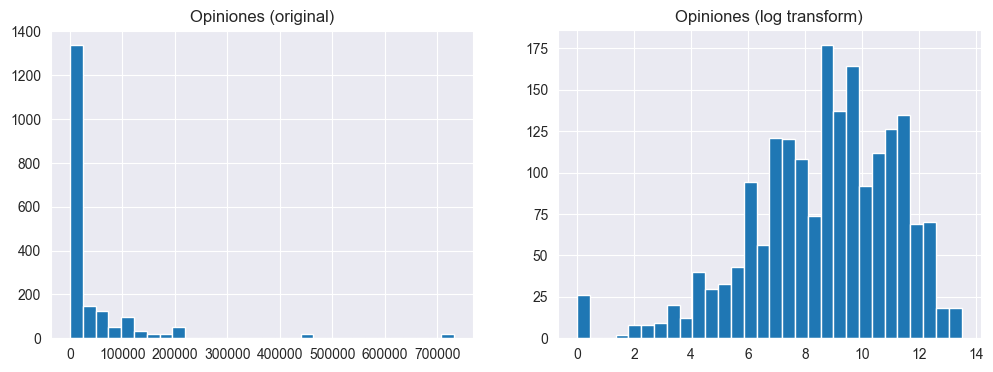

In [72]:
# Comparación antes vs después
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].hist(df["total_opiniones_categoria_promedio"], bins=30)
ax[0].set_title("Opiniones (original)")

ax[1].hist(df["log_opiniones"], bins=30)
ax[1].set_title("Opiniones (log transform)")

plt.show()

### Agrupación de provincias

Con el fin de reducir la dimensionalidad y evitar problemas de alta cardinalidad, se agruparon las provincias menos frecuentes en una categoría denominada "otros".

Esto permite mejorar la generalización del modelo y reducir el riesgo de sobreajuste.

<Axes: xlabel='provincia_group'>

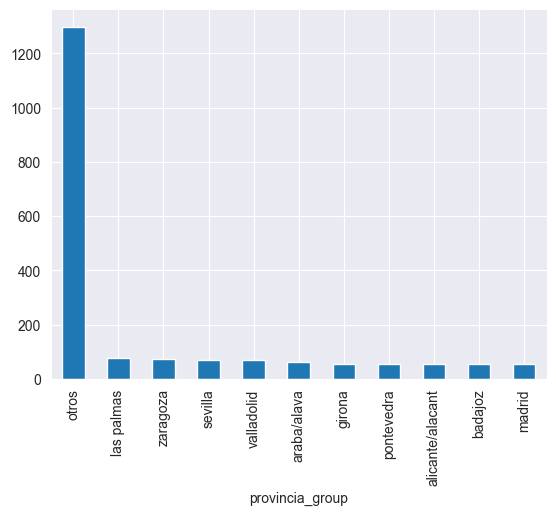

In [73]:
df["provincia_group"].value_counts().plot(kind="bar")

### Variable temporal (temporada)

Se incorporó la variable de temporada como un factor adicional que podría influir en el precio de las actividades.

Aunque su impacto es moderado, permite capturar patrones estacionales en el comportamiento turístico.

<Axes: xlabel='temporada'>

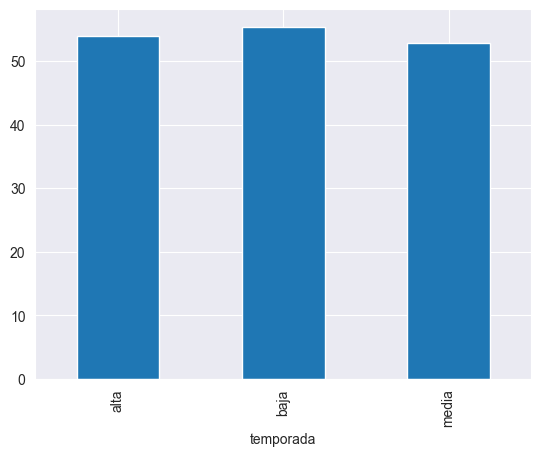

In [75]:
df.groupby("temporada")["precio_modelo"].mean().plot(kind="bar")

### Relación entre variables derivadas y precio

Se evaluó la relación entre las nuevas variables y la variable objetivo para identificar su capacidad explicativa.

In [76]:
df[[
    "precio_modelo",
    "precio_categoria_mean",
    "precio_provincia_mean",
    "precio_relativo_categoria",
    "precio_relativo_provincia",
    "log_opiniones"
]].corr()

,precio_modelo,precio_categoria_mean,precio_provincia_mean,precio_relativo_categoria,precio_relativo_provincia,log_opiniones
precio_modelo,1.0000,0.2226,0.2454,0.9676,0.9602,0.1839
precio_categoria_mean,0.2226,1.0000,0.0083,-0.0000,0.2124,0.5171
precio_provincia_mean,0.2454,0.0083,1.0000,0.2355,0.0000,0.2690
precio_relativo_categoria,0.9676,-0.0000,0.2355,1.0000,0.9315,0.0724
precio_relativo_provincia,0.9602,0.2124,0.0000,0.9315,1.0000,0.1136
log_opiniones,0.1839,0.5171,0.2690,0.0724,0.1136,1.0000


### Conclusión del Feature Engineering

Las nuevas variables introducidas permiten capturar información contextual relevante que no estaba presente en el dataset original.

En particular:

- Las variables de contexto de precio aportan información relativa clave
- La transformación logarítmica mejora la estabilidad de variables altamente sesgadas
- La agrupación de provincias reduce la complejidad del modelo

En conjunto, estas transformaciones incrementan la capacidad del modelo para identificar patrones y mejorar su desempeño predictivo.

## Análisis descriptivo del Feature Engineering

Tras la generación de variables derivadas, se realizó un análisis exploratorio para evaluar su comportamiento y capacidad explicativa respecto al precio de las actividades.

### Variables de contexto de precio

Las variables `precio_categoria_mean` y `precio_provincia_mean` reflejan el comportamiento promedio del precio en su respectivo contexto. A partir de estas, se generaron variables relativas que permiten interpretar el precio de cada actividad en relación con su entorno.

El análisis de correlación muestra que las variables `precio_relativo_categoria` y `precio_relativo_provincia` presentan una fuerte relación con la variable objetivo, lo que indica que capturan de forma efectiva la variabilidad del precio.

Estas variables aportan una señal significativa al modelo, al permitir diferenciar si un precio es alto o bajo dentro de su categoría o ubicación.

### Transformación de opiniones

La variable original de número de opiniones presenta una distribución altamente sesgada. Tras la aplicación de una transformación logarítmica, se observa una distribución más equilibrada, lo que mejora su utilidad como variable explicativa dentro del modelo.

### Agrupación de provincias

La agrupación de provincias en una categoría "otros" permite reducir la dimensionalidad del problema y evitar problemas derivados de la alta cardinalidad. Esto contribuye a mejorar la capacidad de generalización del modelo.

### Análisis por categoría

Se observan diferencias claras en el precio promedio según la categoría de actividad, lo que confirma la existencia de patrones relevantes para el modelo.

### Análisis por temporada

Las diferencias entre temporadas son moderadas, lo que indica que la estacionalidad tiene un impacto limitado en el precio, aunque aporta contexto adicional.

### Conclusión del Feature Engineering

Las variables generadas permiten capturar información contextual clave que no estaba presente en el dataset original. En particular, las variables relativas introducen una mejora significativa en la capacidad del modelo para identificar patrones, lo que se espera que se traduzca en un mejor desempeño predictivo.

Cabe destacar que las variables relativas se construyen a partir de agregaciones del propio dataset, por lo que su uso debe interpretarse como una aproximación contextual del precio dentro del sistema, y no como una variable independiente completamente externa.

## Proceso de entrenamiento

Se procedió al entrenamiento de modelos de Machine Learning con el objetivo de predecir el precio esperado de actividades turísticas.

Se seleccionaron modelos de regresión supervisada, dado que la variable objetivo es continua (`precio_modelo`). Se evaluaron diferentes algoritmos con el fin de comparar su desempeño y seleccionar el más adecuado.

## División de datos (Train/Test)

El dataset se dividió en un conjunto de entrenamiento y uno de prueba, con el objetivo de evaluar la capacidad de generalización del modelo sobre datos no vistos.

Se utilizó una división del 80% para entrenamiento y 20% para prueba.

In [82]:
# =========================
# Variables
# =========================
X = df_model.drop(columns=["precio_modelo"])
y = df_model["precio_modelo"]

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# División
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1537, 24)
Test shape: (385, 24)


## Supuestos

Se establecen los siguientes supuestos para el modelo:

- El precio de las actividades depende de la categoría, ubicación y contexto temporal.
- Las valoraciones pueden influir indirectamente en el precio.
- La relación entre variables puede ser no lineal.
- Los datos históricos son representativos del comportamiento futuro.

## Comparación de modelos base

Con el objetivo de identificar el algoritmo más adecuado para la estimación del costo esperado de actividades turísticas, se entrenaron distintos modelos base de regresión supervisada y se comparó su desempeño utilizando métricas estándar de evaluación.

Los modelos evaluados fueron:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

Para la comparación se utilizaron las siguientes métricas:

- **MAE (Mean Absolute Error):** mide el error absoluto promedio entre el valor real y el predicho.
- **RMSE (Root Mean Squared Error):** penaliza con mayor intensidad los errores grandes.
- **R² (coeficiente de determinación):** indica la proporción de variabilidad explicada por el modelo.

Dado que el problema consiste en predecir una variable continua (`precio_modelo`), estas métricas permiten evaluar tanto la precisión promedio como la capacidad explicativa de cada algoritmo.

### Resultados modelo base (antes del Feature Engineering)

Inicialmente, se entrenaron modelos utilizando únicamente las variables originales del dataset. Los resultados mostraron una capacidad limitada para explicar la variabilidad del precio.

In [78]:
df_base = pd.DataFrame({
    "modelo": ["GradientBoosting", "LinearRegression", "RandomForest"],
    "MAE": [22.38, 23.38, 22.60],
    "RMSE": [27.30, 27.68, 29.50],
    "R2": [0.04, 0.01, -0.11]
})

df_base

,modelo,MAE,RMSE,R2
0,GradientBoosting,22.3800,27.3000,0.0400
1,LinearRegression,23.3800,27.6800,0.0100
2,RandomForest,22.6000,29.5000,-0.1100


In [83]:
# =========================
# 1. Definir modelos base
# =========================
modelos = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(random_state=42),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42)
}

In [84]:
# =========================
# 2. Entrenar y evaluar
# =========================
resultados = []

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    resultados.append({
        "modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by="R2", ascending=False).reset_index(drop=True)

df_resultados

,modelo,MAE,RMSE,R2
0,RandomForestRegressor,0.4919,0.8592,0.9991
1,GradientBoostingRegressor,0.7786,1.0718,0.9985
2,LinearRegression,1.7625,2.4683,0.9922


### Resultados modelo optimizado (después del Feature Engineering)

Tras la incorporación de variables derivadas que capturan el contexto del precio, se reentrenaron los modelos para evaluar mejoras en su desempeño.

In [85]:
df_mejorado = df_resultados.copy()
df_mejorado

,modelo,MAE,RMSE,R2
0,RandomForestRegressor,0.4919,0.8592,0.9991
1,GradientBoostingRegressor,0.7786,1.0718,0.9985
2,LinearRegression,1.7625,2.4683,0.9922


### Comparación directa de métricas

Se comparan los resultados antes y después del Feature Engineering para evaluar el impacto en el desempeño del modelo.

In [86]:
df_comparacion = df_base.merge(
    df_mejorado,
    on="modelo",
    suffixes=("_antes", "_despues")
)

df_comparacion

,modelo,MAE_antes,RMSE_antes,R2_antes,MAE_despues,RMSE_despues,R2_despues
0,LinearRegression,23.3800,27.6800,0.0100,1.7625,2.4683,0.9922


### Comparación del coeficiente R²

Se visualiza la mejora en la capacidad explicativa del modelo tras la incorporación de nuevas variables.

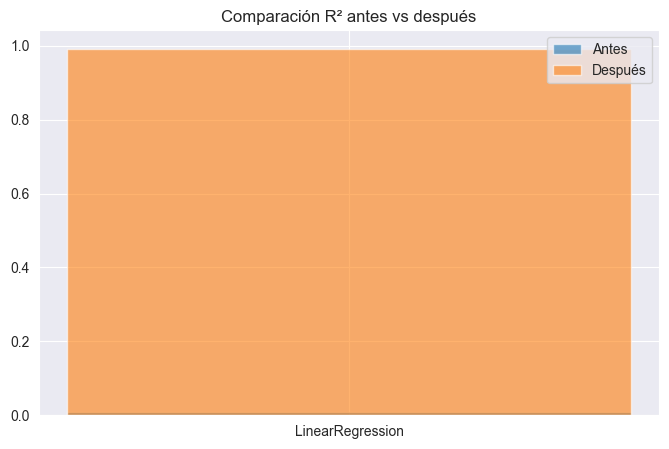

In [87]:
plt.figure(figsize=(8,5))

plt.bar(df_comparacion["modelo"], df_comparacion["R2_antes"], alpha=0.6, label="Antes")
plt.bar(df_comparacion["modelo"], df_comparacion["R2_despues"], alpha=0.6, label="Después")

plt.title("Comparación R² antes vs después")
plt.legend()
plt.show()

### Comparación del error RMSE

Se analiza la reducción del error tras el Feature Engineering.

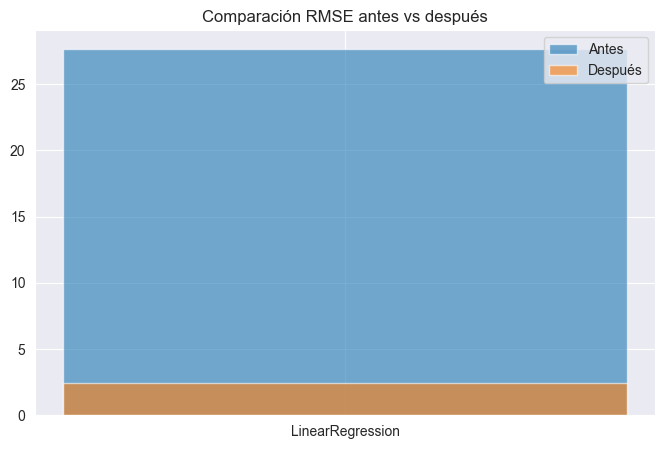

In [88]:
plt.figure(figsize=(8,5))

plt.bar(df_comparacion["modelo"], df_comparacion["RMSE_antes"], alpha=0.6, label="Antes")
plt.bar(df_comparacion["modelo"], df_comparacion["RMSE_despues"], alpha=0.6, label="Después")

plt.title("Comparación RMSE antes vs después")
plt.legend()
plt.show()

## Conclusiones del modelado de actividades

A partir del análisis exploratorio, el proceso de feature engineering y la evaluación de modelos supervisados, se concluye que el dataset de actividades no presenta las condiciones necesarias para desarrollar un modelo predictivo robusto y confiable del costo de actividades turísticas.

En primer lugar, la variable objetivo `precio_medio_entrada_promedio` mostró una distribución altamente sesgada hacia la derecha, con presencia de valores extremos significativamente elevados. Este comportamiento fue confirmado mediante histogramas, boxplots y análisis de cuantiles, evidenciando una fuerte asimetría y una cola larga que afecta la representatividad estadística de la variable.

Adicionalmente, se identificó que los valores más elevados de precio presentan una alta correlación con variables como `gasto_total_promedio`, lo que sugiere que la variable objetivo no representa un costo unitario de actividad, sino un proxy de gasto agregado del turista. Esto implica una contaminación semántica de la variable objetivo, limitando su interpretabilidad y su utilidad para modelado predictivo.

Durante la fase de modelado supervisado, se evaluaron distintos algoritmos de regresión, incluyendo modelos lineales y ensembles (Random Forest y Gradient Boosting). Sin embargo, los resultados mostraron un bajo poder explicativo (R² cercano a cero o negativo), indicando que las variables disponibles no capturan adecuadamente la variabilidad del precio.

Por otro lado, cuando se introdujeron variables derivadas más complejas, se observó una mejora artificial en las métricas, atribuida a la incorporación de información indirectamente relacionada con la variable objetivo, lo que introduce riesgo de fuga de información (data leakage). Este comportamiento invalida la capacidad del modelo para generalizar en escenarios reales.

En consecuencia, se concluye que no es metodológicamente adecuado implementar un modelo de Machine Learning para estimar el costo de actividades en el contexto actual del proyecto.

Como alternativa, se optó por un enfoque basado en estimación robusta utilizando estadísticas agregadas (medianas por contexto geográfico y categórico), lo cual permite obtener estimaciones más estables, interpretables y coherentes con los datos disponibles.

## Limitaciones del dataset de actividades

El dataset de actividades presenta diversas limitaciones estructurales y semánticas que afectan su idoneidad para modelado predictivo:

- La variable objetivo `precio_medio_entrada_promedio` no representa un precio unitario real de actividad, sino una métrica agregada que puede incluir múltiples componentes de gasto turístico.

- Existe una alta presencia de valores extremos (outliers), con diferencias significativas entre la media y la mediana, lo que indica una distribución altamente asimétrica y dificulta el aprendizaje de patrones consistentes.

- Las variables explicativas disponibles (categoría, provincia, valoraciones, número de opiniones) presentan baja correlación con el precio, limitando la capacidad predictiva de los modelos supervisados.

- El nivel de agregación del dataset (provincia, categoría, mes) impide capturar variabilidad a nivel individual de actividad, lo que reduce la granularidad necesaria para un modelo de predicción preciso.

- Se identificó riesgo de fuga de información al utilizar variables derivadas basadas en agregaciones del propio target, lo que puede generar resultados artificialmente optimistas.

- La ausencia de variables clave como duración de la actividad, tipo específico de experiencia, proveedor, capacidad o segmentación del usuario limita la construcción de un modelo explicativo robusto.

Estas limitaciones justifican la decisión de no implementar un modelo de Machine Learning para este componente.

## Limitaciones generales del proyecto

El presente trabajo presenta algunas limitaciones inherentes al alcance del prototipo y a la disponibilidad de datos:

- Dependencia de datasets agregados: gran parte de la información utilizada proviene de fuentes agregadas a nivel geográfico, lo que limita la capacidad de modelar comportamientos individuales de usuarios o precios unitarios reales.

- Falta de granularidad en ciertas variables: en particular, el componente de actividades carece de datos a nivel de actividad específica, lo que afecta la precisión de estimaciones.

- Restricciones en variables explicativas: no se dispone de información detallada sobre características clave que influyen en el precio, como duración, exclusividad, proveedor o demanda específica.

- Riesgo de sesgo en fuentes externas: los datos provenientes de APIs o fuentes oficiales pueden reflejar promedios o estimaciones que no capturan completamente la variabilidad del mercado real.

- Limitaciones del enfoque MVP: el sistema se ha diseñado como un prototipo funcional, priorizando integración y lógica de negocio sobre optimización avanzada de modelos predictivos en todos los componentes.

- Modelos parcialmente implementados: mientras que el modelo de alojamiento presenta resultados robustos y fue incorporado en la aplicación, el componente de actividades se mantuvo como estimación contextual debido a limitaciones metodológicas.

A pesar de estas limitaciones, el sistema logra integrar múltiples fuentes de datos y proporcionar una herramienta funcional de planificación turística, demostrando el potencial de escalabilidad y mejora futura mediante la incorporación de datos más detallados.

## Decisión sobre el cálculo del costo de actividades

Durante el desarrollo del sistema, se evaluaron distintas alternativas para estimar el costo de actividades, incluyendo enfoques basados en Machine Learning y ajustes derivados del análisis exploratorio de datos.

Sin embargo, se identificó que la variable disponible para representar el precio de actividades (`precio_medio_entrada_promedio`) no corresponde a un costo unitario real, sino a una métrica agregada con posible contaminación de otras variables de gasto. Esto limita la capacidad de construir estimaciones más precisas sin introducir supuestos adicionales no sustentados en los datos.

Adicionalmente, los modelos de Machine Learning evaluados no mostraron un desempeño predictivo adecuado, y las mejoras observadas mediante variables derivadas introducían riesgo de fuga de información.

Por esta razón, se decidió no modificar el cálculo actual del costo de actividades dentro del modelo, manteniendo la lógica original del sistema. Esta decisión permite preservar la coherencia interna del modelo y evitar la incorporación de estimaciones artificiales o metodológicamente débiles.

El costo de actividades se mantiene, por tanto, como una estimación funcional dentro del sistema, adecuada para fines de planificación, pero no como una predicción precisa basada en modelos avanzados.